#  Bigram Language Model

**Author:** Prakash Kumar Sah  
**Notebook:** Bigram_Language_Model.ipynb

---

## Objective

Build a **character-level Bigram Language Model** using PyTorch.

In a bigram model, the probability of the next token depends **only on the previous token**:

\[
P(w_t)=P(w_1)\prod_{i=2}^{n}P(w_i|w_{i-1})
\]

This notebook is written in a tutorial style suitable for learning, interviews, GitHub, and portfolios.


## 1️ Import Libraries & Configure Environment

In [13]:
import torch
import torch.nn as nn
from torch.nn import functional as F
import matplotlib.pyplot as plt

torch.manual_seed(1337)
device="cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cuda


## 2️ Hyperparameters

In [14]:
batch_size=32
block_size=8
max_iters=5000
eval_interval=500
eval_iters=250
learning_rate=1e-2

## 3️ Load Dataset

Place **ROMEO_JULIET.txt** in the same directory as this notebook.


In [15]:
with open("ROMEO_JULIET.txt","r",encoding="utf-8") as f:
    text=f.read()

chars=sorted(list(set(text)))
vocab_size=len(chars)

stoi={c:i for i,c in enumerate(chars)}
itos={i:c for i,c in enumerate(chars)}

encode=lambda s:[stoi[c] for c in s]
decode=lambda l:"".join(itos[i] for i in l)

data=torch.tensor(encode(text),dtype=torch.long)
print("Characters:",vocab_size)
print("Dataset size:",len(data))

Characters: 70
Dataset size: 141476


## 4️ Train / Validation Split

In [16]:
n=int(0.9*len(data))
train_data=data[:n]
val_data=data[n:]

def get_batch(split):
    source=train_data if split=="train" else val_data
    ix=torch.randint(len(source)-block_size,(batch_size,))
    x=torch.stack([source[i:i+block_size] for i in ix])
    y=torch.stack([source[i+1:i+block_size+1] for i in ix])
    return x.to(device),y.to(device)

## 5️ Build the Bigram Language Model

Each input character directly learns logits for predicting the next character using an embedding table.


In [17]:
class BigramLanguageModel(nn.Module):
    def __init__(self,vocab_size):
        super().__init__()
        self.token_embedding_table=nn.Embedding(vocab_size,vocab_size)

    def forward(self,idx,targets=None):
        logits=self.token_embedding_table(idx)
        if targets is None:
            return logits,None
        B,T,C=logits.shape
        logits=logits.reshape(B*T,C)
        targets=targets.reshape(B*T)
        loss=F.cross_entropy(logits,targets)
        return logits,loss

    def generate(self,idx,max_new_tokens):
        for _ in range(max_new_tokens):
            logits,_=self(idx)
            logits=logits[:,-1,:]
            probs=F.softmax(logits,dim=-1)
            idx_next=torch.multinomial(probs,1)
            idx=torch.cat((idx,idx_next),dim=1)
        return idx

## 6️ Evaluation Helper

In [18]:
@torch.no_grad()
def estimate_loss(model):
    model.eval()
    out={}
    for split in ["train","val"]:
        losses=torch.zeros(eval_iters)
        for k in range(eval_iters):
            X,Y=get_batch(split)
            _,loss=model(X,Y)
            losses[k]=loss.item()
        out[split]=losses.mean()
    model.train()
    return out

## 7️ Create Model & Optimizer

In [19]:
model=BigramLanguageModel(vocab_size).to(device)
optimizer=torch.optim.AdamW(model.parameters(),lr=learning_rate)

## 8️ Generate Text Before Training

In [20]:
model.eval()
context=torch.zeros((1,1),dtype=torch.long,device=device)
print(decode(model.generate(context,300)[0].tolist()))
model.train()


q”goycGdUalQed;xk.a’yR:IB. KuN
kAq_qklyEI.DYjA]bVwMR:-?[PACC_bib
i]A_Z “ui]fQviN,S“Nw;u’cd_e]H!IpbOf[Gx?[J”rU[y”gGta’_Myæo“Qn]
_p?,,IPupgF’cædr!!,Z!&[Boe_m[y‘cfhAjK_f_HUohd”SBmV[jKIJdBspw HtVb.EByJl ”;s“Gp;”S[kln!qfmMm&oI’Y‘AS;s:i“Gar
VklwZz‘—YvqkPojKr]i”xuzgzMmsES”KL;”EgVqk_y?h_UtkrlAGumrxpemQmuVll


BigramLanguageModel(
  (token_embedding_table): Embedding(70, 70)
)

## 9️ Training

In [21]:
steps=[]
train_losses=[]
val_losses=[]

for step in range(max_iters):
    if step % eval_interval==0 or step==max_iters-1:
        losses=estimate_loss(model)
        print(f"Step {step:5d} | Train {losses['train']:.4f} | Val {losses['val']:.4f}")
        steps.append(step)
        train_losses.append(losses["train"].item())
        val_losses.append(losses["val"].item())

    xb,yb=get_batch("train")
    _,loss=model(xb,yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

Step     0 | Train 4.7856 | Val 4.8168
Step   500 | Train 2.5589 | Val 2.5882
Step  1000 | Train 2.4503 | Val 2.4881
Step  1500 | Train 2.4416 | Val 2.4595
Step  2000 | Train 2.4262 | Val 2.4567
Step  2500 | Train 2.4287 | Val 2.4634
Step  3000 | Train 2.4244 | Val 2.4554
Step  3500 | Train 2.4210 | Val 2.4574
Step  4000 | Train 2.4308 | Val 2.4599
Step  4500 | Train 2.4179 | Val 2.4605
Step  4999 | Train 2.4179 | Val 2.4544


## 10 Generate Text After Training

In [22]:
model.eval()
print(decode(model.generate(context,1000)[0].tolist()))



NCU[_ETh ISer fincht fan a thysary y figh, I h the?
DYoy sh
Thy benouculd se t Bu and a nthou he lemere,

TIEO Stheere Ve ousand y l!
N.
’e,
N.
Asethe aint hig ouiveicon lands woll s: cond,
Anore!
PRO.
Hearoole nchansether pis lern tcoo be ithe: Coungh,
As me, serye BET.—
NERont io m’lld ye.
Whentor g the, then, ntho;
Manto t woun a worthetive, SCacon wintwouaneatrt?


Fot I l ffean,
By t Mone ithy w fUR.
DOLAseadan me atatloortritow endrd o.
Isy hrs;

Anicchere, be wid Hond the l t awo wan’ meno wated ame owayo we._EO.

OLItheil y; telichrar,

Justor Fornvest, ather I w, JUTu p outad f t?
No yby sulopo trcoruched u d the thindit clit toot ingh arere.

Wixinde, le.
Ay u f tousorromy han paffit? bea f cate; bereresThatool d y bero nd, w f.—
 We wegubeppomok, ced o y ay
Hernto.
Me, w n’lke al me mo inowie d t ay aveswilll’ twe oeadir me s y hoferir’t wLousthe bar ad ar y me wed ybereanl maneam n lest me tsan aye, yoxe ow thy as thiave LIO.
Buch erurimend, Kil’
SERothermyonotak’ss, d me

## 1️1 Visualize Loss

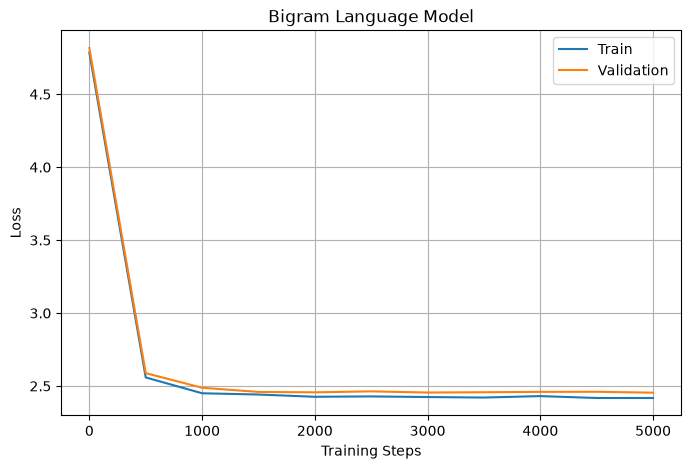

In [23]:
plt.figure(figsize=(8,5))
plt.plot(steps,train_losses,label="Train")
plt.plot(steps,val_losses,label="Validation")
plt.xlabel("Training Steps")
plt.ylabel("Loss")
plt.title("Bigram Language Model")
plt.grid(True)
plt.legend()
plt.show()

## 1️2 Save Model

In [24]:
torch.save({
    "model_state_dict":model.state_dict(),
    "vocab":chars,
    "vocab_size":vocab_size
},"bigram_model.pt")
print("Model saved successfully.")

Model saved successfully.


# Key Takeaways

- Bigram predicts the next character using only the previous character.
- Uses an embedding table as the learnable probability matrix.
- Cross-entropy optimizes next-character prediction.
- This notebook is the foundation for building Transformer-based language models.
